# CIM 2025-2026 — M.EEC0045
## Lab Assignment 3 — Parte 1: Hybrid Video Encoder
### Experiments with Hybrid Video Encoding/Decoding Scheme

Este notebook implementa a **Parte 1** do Assignment 3, cobrindo:
- **1.1.i** — Importação de sequências de vídeo/imagens e conversão de espaço de cor
- **1.1.ii** — Estimação de movimento (block matching) por macrobloco
- **1.1.iii** — Variação do tamanho do macrobloco (16×16 até 4×4)
- **1.1.iv** — Visualização dos vetores de movimento
- **1.1.v** — Transformada DCT2 em blocos 8×8
- **1.1.vi** — Quantização matricial de blocos 8×8 (modos I, P, B)
- **1.2** — Script principal do encoder com estrutura GOP, armazenamento comprimido e análise de bits

> **Nota:** Os scripts `extractFramesFromVideoAndCrop.ipynb`, `imageQualityMetrics.ipynb` e `MEblockMatching.ipynb` fornecidos pela professora são **reutilizados integralmente** neste notebook, sem alterações ao código original.

---
## 0. Importações e Dependências

In [3]:
import cv2
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.fftpack import dct, idct
from skimage.metrics import structural_similarity as ssim
from collections import defaultdict
import heapq

print("Todas as dependências importadas com sucesso.")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

Todas as dependências importadas com sucesso.
OpenCV version: 4.13.0
NumPy version: 2.4.2


---
## 1.1.i — Importação de Sequências e Conversão de Espaço de Cor

As funções `extract_frames` e `crop_frames_to_multiples_of_8` são **retiradas directamente** do script `extractFramesFromVideoAndCrop.ipynb` fornecido pela professora, sem qualquer alteração.

In [4]:
# =============================================================
# CÓDIGO ORIGINAL DA PROFESSORA — extractFramesFromVideoAndCrop.ipynb
# (copiado sem alterações)
# =============================================================

def extract_frames(video_path):
    """Extrai frames de um vídeo em escala de cinza."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame)
    cap.release()
    return frames

def crop_frames_to_multiples_of_8(video_path):
    """Extrai frames de um vídeo, cortando para múltiplos de 8x8."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, image = cap.read()
        if not ret:
            break
        height, width = image.shape[:2]
        new_height = (height // 8) * 8
        new_width  = (width  // 8) * 8
        frame = image[:new_height, :new_width]
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame)
    cap.release()
    return frames

# =============================================================
# FUNÇÕES ADICIONAIS (1.1.i) — importação de sequência de imagens BMP
# e conversão parametrizada de espaço de cor
# =============================================================

COLOR_SPACES = {
    'YCrCb' : cv2.COLOR_BGR2YCrCb,
    'HSV'   : cv2.COLOR_BGR2HSV,
    'LAB'   : cv2.COLOR_BGR2LAB,
    'GRAY'  : cv2.COLOR_BGR2GRAY,
    'YUV'   : cv2.COLOR_BGR2YUV,
}

def load_image_sequence(folder_path, extension='.bmp', color_space='YCrCb'):
    """
    1.1.i — Importa uma sequência de imagens a partir de uma pasta,
    converte para o espaço de cor especificado (parâmetro) e devolve:
      - frames_y   : canal de luminância (Y) de cada frame
      - frames_full: imagem completa convertida (todos os canais)

    Parâmetros
    ----------
    folder_path  : caminho para a pasta com as imagens
    extension    : extensão dos ficheiros ('.bmp', '.png', etc.)
    color_space  : espaço de cor destino ('YCrCb', 'YUV', 'HSV', 'LAB', 'GRAY')
    """
    if color_space not in COLOR_SPACES:
        raise ValueError(f"Espaço de cor inválido. Escolha entre: {list(COLOR_SPACES.keys())}")

    files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(extension)
    ])

    if not files:
        raise FileNotFoundError(f"Nenhum ficheiro '{extension}' encontrado em {folder_path}")

    frames_y    = []
    frames_full = []

    for fname in files:
        img_bgr = cv2.imread(os.path.join(folder_path, fname))
        if img_bgr is None:
            print(f"[AVISO] Não foi possível carregar {fname}")
            continue

        # Cortar para múltiplos de 8
        h, w = img_bgr.shape[:2]
        img_bgr = img_bgr[:(h//8)*8, :(w//8)*8]

        if color_space == 'GRAY':
            converted = cv2.cvtColor(img_bgr, COLOR_SPACES['GRAY'])
            frames_y.append(converted)
            frames_full.append(converted)
        else:
            converted = cv2.cvtColor(img_bgr, COLOR_SPACES[color_space])
            y_channel = converted[:, :, 0]   # canal Y (luminância)
            frames_y.append(y_channel)
            frames_full.append(converted)

    print(f"[load_image_sequence] Carregados {len(frames_y)} frames de '{folder_path}'")
    print(f"  Espaço de cor: {color_space} | Resolução: {frames_y[0].shape}")
    return frames_y, frames_full


def display_frames(frames_y, title='Sequência de frames (Y)', n_show=5):
    """Apresenta os primeiros n_show frames do canal Y."""
    n = min(n_show, len(frames_y))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(frames_y[i], cmap='gray')
        ax.set_title(f'Frame {i+1}')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

print("Funções 1.1.i definidas com sucesso.")

Funções 1.1.i definidas com sucesso.


[load_image_sequence] Carregados 11 frames de 'video sequences/sequence of still images - car'
  Espaço de cor: YCrCb | Resolução: (256, 256)


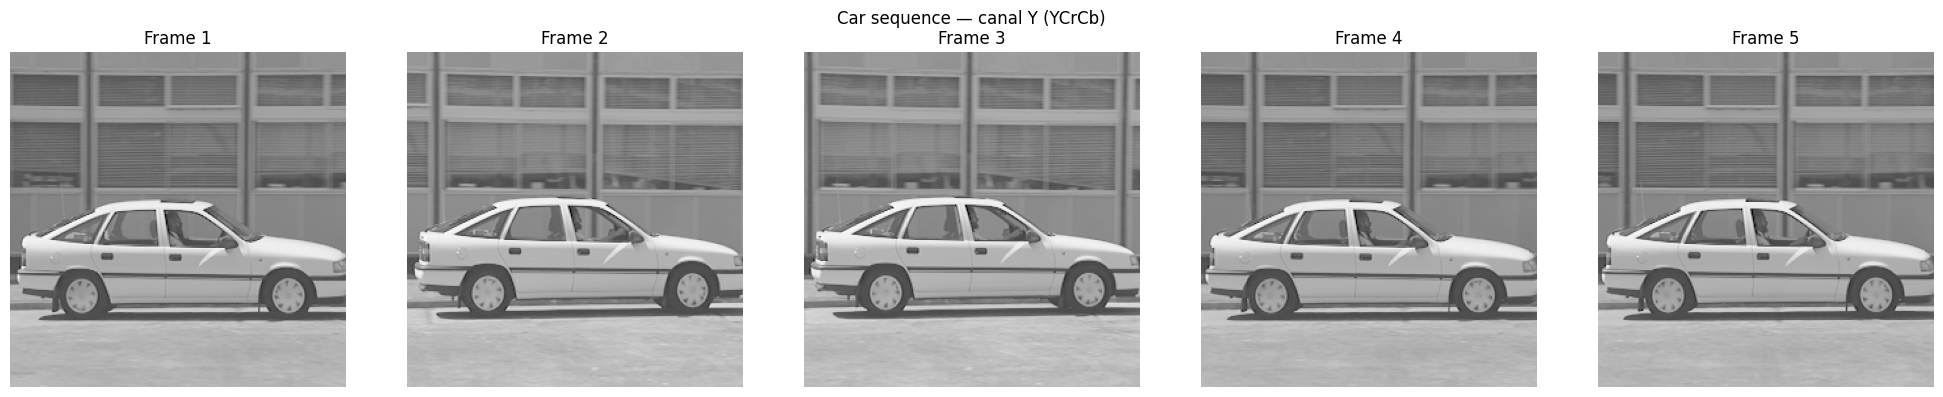

[VIDEO] Extraídos 240 frames do vídeo.


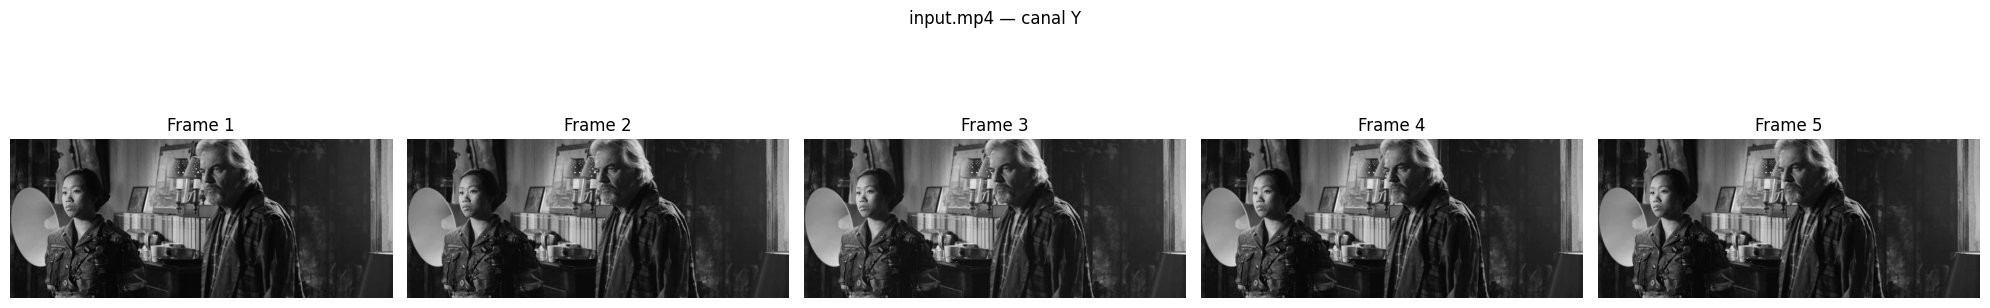

In [5]:
# --- Demonstração 1.1.i ---
CAR_FOLDER = 'video sequences/sequence of still images - car'
VIDEO_PATH = 'video sequences/input.mp4'

# Sequência de imagens BMP (pasta car)
if os.path.isdir(CAR_FOLDER):
    frames_y_car, frames_full_car = load_image_sequence(CAR_FOLDER, extension='.bmp', color_space='YCrCb')
    display_frames(frames_y_car, title='Car sequence — canal Y (YCrCb)', n_show=5)
else:
    print(f"[INFO] Pasta '{CAR_FOLDER}' não encontrada.")

# Vídeo MP4 (usando a função da professora)
if os.path.isfile(VIDEO_PATH):
    frames_video = crop_frames_to_multiples_of_8(VIDEO_PATH)
    print(f"[VIDEO] Extraídos {len(frames_video)} frames do vídeo.")
    display_frames(frames_video, title='input.mp4 — canal Y', n_show=5)
else:
    print(f"[INFO] Vídeo '{VIDEO_PATH}' não encontrado.")

---
## 1.1.ii & 1.1.iii — Estimação de Movimento (Block Matching)

A função `block_matching` base é **retirada directamente** do script `MEblockMatching.ipynb` fornecido pela professora.  
A versão extendida (1.1.iii) adiciona suporte a tamanhos de MB variáveis (16×16 → 4×4) e modos I/P/B.

In [6]:
# =============================================================
# CÓDIGO ORIGINAL DA PROFESSORA — MEblockMatching.ipynb
# (copiado sem alterações)
# =============================================================

def mse(block1, block2):
    return np.mean((block1 - block2) ** 2)

def block_matching(ref_frame, target_frame, block_size=16, search_range=8):
    """Estimação de movimento por full-search block matching (professora)."""
    height, width = ref_frame.shape
    motion_vectors = np.zeros((height // block_size, width // block_size, 2), dtype=int)

    for i in range(0, height - block_size + 1, block_size):
        for j in range(0, width - block_size + 1, block_size):
            best_mse = float('inf')
            best_mv  = (0, 0)
            block    = target_frame[i:i+block_size, j:j+block_size]

            for x in range(-search_range, search_range + 1):
                for y in range(-search_range, search_range + 1):
                    if (0 <= i + x < height - block_size + 1 and
                        0 <= j + y < width  - block_size + 1):
                        candidate = ref_frame[i+x : i+x+block_size, j+y : j+y+block_size]
                        error = mse(block, candidate)
                        if error < best_mse:
                            best_mse = error
                            best_mv  = (x, y)

            motion_vectors[i // block_size, j // block_size] = best_mv
    return motion_vectors

# =============================================================
# FUNÇÕES ADICIONAIS (1.1.ii / 1.1.iii)
# =============================================================

def compute_motion_and_residual(anchor_frame, ref_frames, mode='P',
                                 pixel_accuracy=1, search_range=15,
                                 block_size=16, min_block_size=16):
    """
    1.1.ii / 1.1.iii — Calcula vetores de movimento e frame residual.

    Parâmetros
    ----------
    anchor_frame   : frame a codificar (np.ndarray 2D, uint8)
    ref_frames     : lista com 1 frame (modo P) ou 2 frames (modo B)
    mode           : 'I', 'P' ou 'B'
    pixel_accuracy : precisão em pixels (1 = inteiro; sub-pixel não implementado nesta versão)
    search_range   : janela de procura (padrão=15)
    block_size     : tamanho máximo do MB (padrão=16)
    min_block_size : tamanho mínimo do MB — divide recursivamente até este valor

    Retorna
    -------
    mv_list    : lista de tuplos (row_mb, col_mb, dx, dy, tamanho_mb)
    residual   : frame de diferença (int16)
    """
    anchor = anchor_frame.astype(np.int16)
    H, W   = anchor.shape
    residual = np.zeros_like(anchor)
    mv_list  = []

    if mode == 'I':
        # Modo intra — sem predição temporal; residual = frame original
        return [], anchor.copy()

    # Para P e B usa sempre pelo menos ref_frames[0] como referência forward
    ref_fwd = ref_frames[0].astype(np.int16)
    ref_bwd = ref_frames[1].astype(np.int16) if (mode == 'B' and len(ref_frames) > 1) else None

    mb = block_size
    for i in range(0, H - mb + 1, mb):
        for j in range(0, W - mb + 1, mb):
            blk_anchor = anchor[i:i+mb, j:j+mb]

            # --- Forward search ---
            best_mse_fwd = float('inf')
            best_mv_fwd  = (0, 0)
            for dx in range(-search_range, search_range + 1):
                for dy in range(-search_range, search_range + 1):
                    ri, rj = i + dx, j + dy
                    if 0 <= ri < H - mb + 1 and 0 <= rj < W - mb + 1:
                        cand = ref_fwd[ri:ri+mb, rj:rj+mb]
                        err  = float(np.mean((blk_anchor - cand) ** 2))
                        if err < best_mse_fwd:
                            best_mse_fwd = err
                            best_mv_fwd  = (dx, dy)

            dx_f, dy_f = best_mv_fwd
            pred_fwd   = ref_fwd[i+dx_f : i+dx_f+mb, j+dy_f : j+dy_f+mb]

            if mode == 'B' and ref_bwd is not None:
                # --- Backward search ---
                best_mse_bwd = float('inf')
                best_mv_bwd  = (0, 0)
                for dx in range(-search_range, search_range + 1):
                    for dy in range(-search_range, search_range + 1):
                        ri, rj = i + dx, j + dy
                        if 0 <= ri < H - mb + 1 and 0 <= rj < W - mb + 1:
                            cand = ref_bwd[ri:ri+mb, rj:rj+mb]
                            err  = float(np.mean((blk_anchor - cand) ** 2))
                            if err < best_mse_bwd:
                                best_mse_bwd = err
                                best_mv_bwd  = (dx, dy)
                dx_b, dy_b = best_mv_bwd
                pred_bwd   = ref_bwd[i+dx_b : i+dx_b+mb, j+dy_b : j+dy_b+mb]
                # Predição bidireccional = média dos dois
                pred = ((pred_fwd.astype(np.float32) + pred_bwd.astype(np.float32)) / 2).astype(np.int16)
                mv_list.append((i // mb, j // mb, dx_f, dy_f, dx_b, dy_b, mb))
            else:
                pred = pred_fwd
                mv_list.append((i // mb, j // mb, dx_f, dy_f, mb))

            residual[i:i+mb, j:j+mb] = blk_anchor - pred

    return mv_list, residual


print("Funções 1.1.ii / 1.1.iii definidas com sucesso.")

Funções 1.1.ii / 1.1.iii definidas com sucesso.


---
## 1.1.iv — Visualização dos Vetores de Movimento

In [7]:
def plot_motion_vectors(frame, mv_list, mode='P', block_size=16, title='Motion Vectors'):
    """
    1.1.iv — Visualiza os vetores de movimento por macrobloco sobre o frame.

    Parâmetros
    ----------
    frame      : frame de referência (2D, uint8)
    mv_list    : lista devolvida por compute_motion_and_residual
    mode       : 'P' ou 'B'
    block_size : tamanho do MB
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(frame, cmap='gray')

    for mv in mv_list:
        if mode == 'B' and len(mv) == 7:
            row_mb, col_mb, dx_f, dy_f, dx_b, dy_b, mb = mv
        else:
            row_mb, col_mb, dx_f, dy_f, mb = mv[:5]
            dx_b, dy_b = None, None

        # Centro do bloco
        cx = col_mb * mb + mb // 2
        cy = row_mb * mb + mb // 2

        # Seta forward (azul)
        if dx_f != 0 or dy_f != 0:
            ax.annotate('', xy=(cx + dy_f, cy + dx_f), xytext=(cx, cy),
                        arrowprops=dict(arrowstyle='->', color='cyan', lw=1.2))

        # Seta backward (vermelho, apenas modo B)
        if dx_b is not None and (dx_b != 0 or dy_b != 0):
            ax.annotate('', xy=(cx + dy_b, cy + dx_b), xytext=(cx, cy),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

    fwd_patch = mpatches.Patch(color='cyan',  label='Forward MV')
    bwd_patch = mpatches.Patch(color='red',   label='Backward MV (B-frame)')
    ax.legend(handles=[fwd_patch, bwd_patch], loc='upper right')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


print("Função 1.1.iv definida com sucesso.")

Função 1.1.iv definida com sucesso.


[block_matching] Shape dos vetores: (16, 16, 2)
  Exemplo MV[0,0]: [1 0]
[compute_motion_and_residual] Modo P | 256 MVs


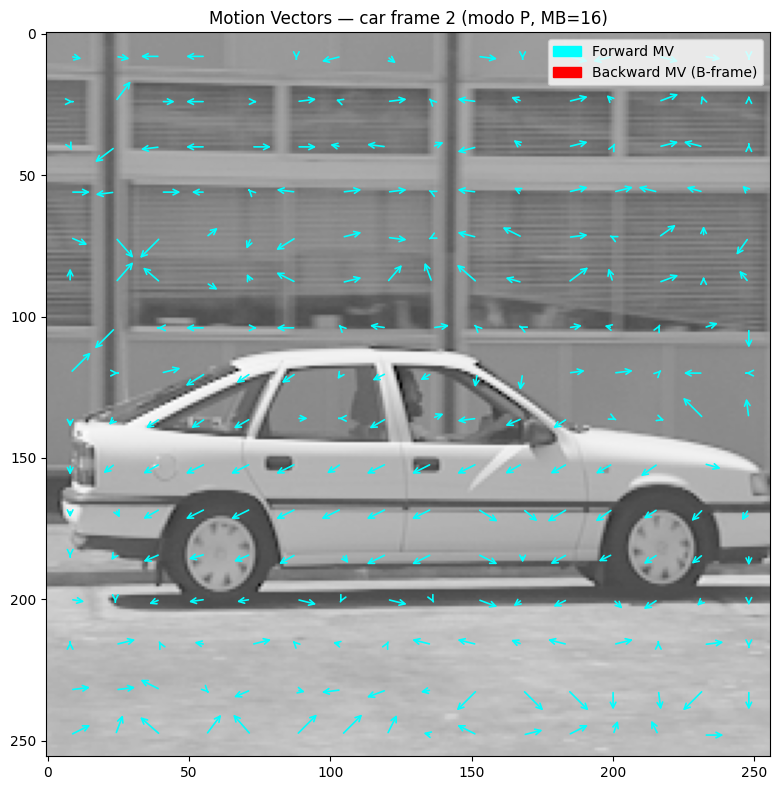

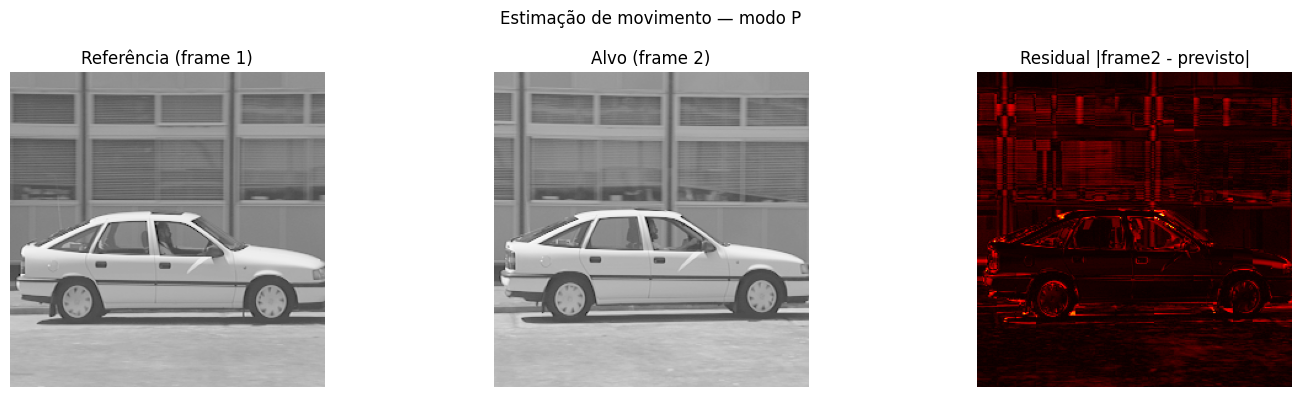

In [8]:
# --- Demonstração 1.1.ii–iv: estimação de MV entre dois frames consecutivos ---
# (usando a sequência 'car' se disponível)

if 'frames_y_car' in dir() and len(frames_y_car) >= 2:
    f0 = frames_y_car[0]
    f1 = frames_y_car[1]

    # Usando a função original da professora (1.1.ii)
    mv_simple = block_matching(f0, f1, block_size=16, search_range=8)
    print(f"[block_matching] Shape dos vetores: {mv_simple.shape}")
    print(f"  Exemplo MV[0,0]: {mv_simple[0,0]}")

    # Usando a função extendida (1.1.ii/iii)
    mv_list_P, residual_P = compute_motion_and_residual(
        f1, [f0], mode='P', search_range=8, block_size=16
    )
    print(f"[compute_motion_and_residual] Modo P | {len(mv_list_P)} MVs")

    # Visualização (1.1.iv)
    plot_motion_vectors(f1, mv_list_P, mode='P', block_size=16,
                        title='Motion Vectors — car frame 2 (modo P, MB=16)')

    # Residual
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(f0,          cmap='gray'); axes[0].set_title('Referência (frame 1)')
    axes[1].imshow(f1,          cmap='gray'); axes[1].set_title('Alvo (frame 2)')
    axes[2].imshow(np.abs(residual_P), cmap='hot'); axes[2].set_title('Residual |frame2 - previsto|')
    for ax in axes: ax.axis('off')
    plt.suptitle('Estimação de movimento — modo P')
    plt.tight_layout(); plt.show()
else:
    print("[INFO] frames_y_car não disponível. Execute a célula de carregamento anterior.")

---
## 1.1.v — Transformada DCT2 em Blocos 8×8

Funções `apply_dct` e `apply_idct` seguem o padrão do **annex** fornecido pela professora (`scipy.fftpack`).

In [9]:
# =============================================================
# CÓDIGO BASEADO NO ANNEX DA PROFESSORA — Transform and Quantization
# (apply_dct / apply_idct sem alterações)
# =============================================================

def apply_dct(block):
    """Aplica a DCT2 a um bloco 8x8 (annex da professora)."""
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def apply_idct(block):
    """Aplica a IDCT2 a um bloco 8x8 (annex da professora)."""
    return idct(idct(block.T, norm='ortho').T, norm='ortho')


def apply_dct_to_frame(frame, block_size=8):
    """
    1.1.v — Aplica a DCT2 a todos os blocos block_size x block_size de um frame.
    Retorna array com os coeficientes DCT (float64, mesma dimensão que o frame).
    """
    H, W = frame.shape
    dct_frame = np.zeros_like(frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = frame[i:i+block_size, j:j+block_size].astype(np.float64)
            if blk.shape == (block_size, block_size):
                dct_frame[i:i+block_size, j:j+block_size] = apply_dct(blk)
    return dct_frame

def apply_idct_to_frame(dct_frame, block_size=8):
    """
    1.1.v — Aplica a IDCT2 a todos os blocos block_size x block_size.
    Retorna frame reconstruído (float64).
    """
    H, W = dct_frame.shape
    rec_frame = np.zeros_like(dct_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = dct_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                rec_frame[i:i+block_size, j:j+block_size] = apply_idct(blk)
    return rec_frame


print("Funções 1.1.v (DCT2) definidas com sucesso.")

Funções 1.1.v (DCT2) definidas com sucesso.


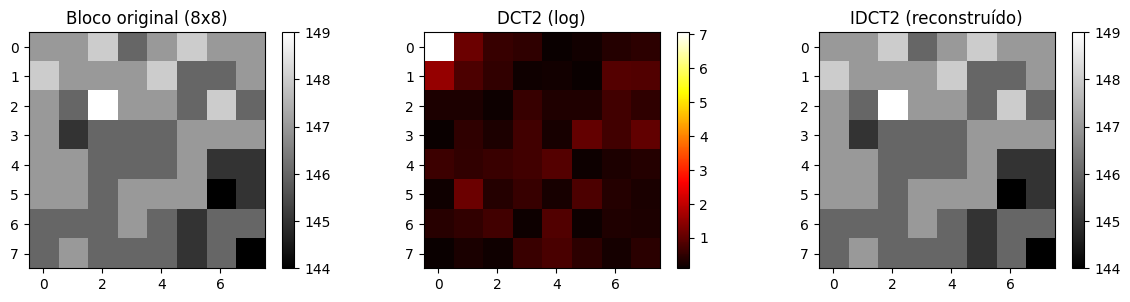

Erro máx. de reconstrução: 8.53e-14


In [10]:
# --- Demonstração 1.1.v: DCT num bloco 8x8 ---
if 'frames_y_car' in dir() and len(frames_y_car) > 0:
    sample_block = frames_y_car[0][:8, :8].astype(np.float64)
    dct_block    = apply_dct(sample_block)
    rec_block    = apply_idct(dct_block)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    im0 = axes[0].imshow(sample_block, cmap='gray')
    axes[0].set_title('Bloco original (8x8)'); plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(np.log1p(np.abs(dct_block)), cmap='hot')
    axes[1].set_title('DCT2 (log)'); plt.colorbar(im1, ax=axes[1])
    im2 = axes[2].imshow(rec_block, cmap='gray')
    axes[2].set_title('IDCT2 (reconstruído)'); plt.colorbar(im2, ax=axes[2])
    plt.tight_layout(); plt.show()
    print(f"Erro máx. de reconstrução: {np.max(np.abs(sample_block - rec_block)):.2e}")
else:
    print("[INFO] frames_y_car não disponível.")

---
## 1.1.vi — Quantização Matricial (Modos I, P, B)

As matrizes de quantização e as funções `quantize` / `dequantize` seguem o **annex** da professora (MPEG defaults).  
A versão aqui distingue a matriz a usar consoante o modo de codificação (I vs P/B).

In [11]:
# =============================================================
# MATRIZES MPEG PADRÃO — do annex da professora (sem alterações)
# Q_INTRA  : usada no modo I (valores de pixel inteiros)
# Q_INTER  : usada nos modos P e B (valores de diferença/residual)
# =============================================================

Q_INTRA = np.array([
    [16, 11, 10, 16, 24,  40,  51,  61],
    [12, 12, 14, 19, 26,  58,  60,  55],
    [14, 13, 16, 24, 40,  57,  69,  56],
    [14, 17, 22, 29, 51,  87,  80,  62],
    [18, 22, 37, 56, 68, 109, 103,  77],
    [24, 35, 55, 64, 81, 104, 113,  92],
    [49, 64, 78, 87,103, 121, 120, 101],
    [72, 92, 95, 98,112, 100, 103,  99],
], dtype=np.float64)

# Matriz inter (MPEG-1 default inter quantization matrix)
Q_INTER = np.array([
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
], dtype=np.float64)


def quantize_block(block, mode='I', scale=1):
    """
    1.1.vi — Quantização de um bloco 8x8 com matriz MPEG.

    Parâmetros
    ----------
    block : array 8x8 de coeficientes DCT
    mode  : 'I' usa Q_INTRA; 'P' ou 'B' usa Q_INTER
    scale : factor de escala do quantizador (quantiser scale factor)

    Retorna
    -------
    Array int com coeficientes quantizados (divisão inteira).
    """
    Q = Q_INTRA if mode == 'I' else Q_INTER
    return np.floor(block / (Q * scale)).astype(int)


def dequantize_block(block, mode='I', scale=1):
    """
    2.1.i — Inversa da quantização (usada também na Parte 2).

    Parâmetros
    ----------
    block : array 8x8 de coeficientes quantizados
    mode  : 'I', 'P' ou 'B'
    scale : mesmo factor usado na quantização
    """
    Q = Q_INTRA if mode == 'I' else Q_INTER
    return (block * (Q * scale)).astype(np.float64)


def quantize_frame(dct_frame, mode='I', scale=1, block_size=8):
    """Aplica quantize_block a todos os blocos de um frame DCT."""
    H, W = dct_frame.shape
    q_frame = np.zeros_like(dct_frame, dtype=int)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = dct_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                q_frame[i:i+block_size, j:j+block_size] = quantize_block(blk, mode, scale)
    return q_frame


def dequantize_frame(q_frame, mode='I', scale=1, block_size=8):
    """Aplica dequantize_block a todos os blocos de um frame quantizado."""
    H, W = q_frame.shape
    dq_frame = np.zeros_like(q_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = q_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                dq_frame[i:i+block_size, j:j+block_size] = dequantize_block(blk, mode, scale)
    return dq_frame


print("Funções 1.1.vi (quantização) definidas com sucesso.")

Funções 1.1.vi (quantização) definidas com sucesso.


---
## 1.2 — Script Principal do Encoder (GOP + armazenamento + análise de bits)

In [12]:
# =============================================================
# CÓDIGO ORIGINAL DA PROFESSORA — imageQualityMetrics.ipynb
# (copiado sem alterações)
# =============================================================

def psnr(original, compressed):
    mse_val = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
    if mse_val == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse_val))

def compute_ssim(original, compressed):
    o = original.astype(np.uint8)
    c = np.clip(compressed, 0, 255).astype(np.uint8)
    return ssim(o, c, data_range=c.max() - c.min())

print("Funções de qualidade (psnr, compute_ssim) prontas.")

Funções de qualidade (psnr, compute_ssim) prontas.


In [13]:
# =============================================================
# UTILITÁRIO: geração da sequência de tipos de frame para uma GOP
# =============================================================

def generate_gop_sequence(n_frames, N, M):
    """
    Gera a sequência de tipos de frame ('I', 'P', 'B') para uma GOP.

    Parâmetros
    ----------
    n_frames : número total de frames
    N        : comprimento da GOP (ex.: 12 → I + 11 P/B)
    M        : distância entre frames âncora P (ex.: M=3 → IBBP BBPBBP ...)
               M=1 → só P-frames (IPPP...)

    Retorna
    -------
    Lista de strings: ['I','B','B','P','B','B','P', ...]
    """
    seq = []
    for idx in range(n_frames):
        pos_in_gop = idx % N
        if pos_in_gop == 0:
            seq.append('I')
        elif pos_in_gop % M == 0:
            seq.append('P')
        else:
            seq.append('B')
    return seq


# Teste rápido
for (N, M) in [(12, 3), (9, 1), (6, 2)]:
    seq = generate_gop_sequence(12, N=N, M=M)
    print(f"N={N}, M={M}: {seq}")

N=12, M=3: ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B']
N=9, M=1: ['I', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'I', 'P', 'P']
N=6, M=2: ['I', 'B', 'P', 'B', 'P', 'B', 'I', 'B', 'P', 'B', 'P', 'B']


In [14]:
# =============================================================
# UTILITÁRIO: contagem de bits (sem Huffman real)
# Conta bits usando representação inteira do array quantizado
# =============================================================

def count_bits(q_frame, mv_list=None):
    """
    Estimativa de bits necessários para armazenar:
    - coeficientes DCT quantizados (não-zero × bits por símbolo)
    - vetores de movimento

    Esta é uma estimativa simplificada; sem codificação entrópica real.
    """
    # Bits para coeficientes: usa ceil(log2(|val|+1)) por coeficiente não-zero
    nonzero = q_frame[q_frame != 0]
    if len(nonzero) == 0:
        coeff_bits = 0
    else:
        coeff_bits = int(np.sum(np.ceil(np.log2(np.abs(nonzero) + 1)) + 1))  # +1 para sinal

    # Bits para MVs: 8 bits por componente × 2 componentes
    mv_bits = 0
    if mv_list:
        mv_bits = len(mv_list) * 2 * 8

    return coeff_bits + mv_bits


print("Utilitário de contagem de bits definido.")

Utilitário de contagem de bits definido.


In [15]:
# =============================================================
# 1.2 — ENCODER PRINCIPAL
# =============================================================

def encode_sequence(frames_y, gop_N=12, gop_M=3,
                    block_size=16, search_range=8,
                    quant_scale=1, output_dir='compressed'):
    """
    1.2 — Codifica uma sequência de frames Y segundo uma estrutura GOP.

    Parâmetros
    ----------
    frames_y     : lista de frames (np.ndarray 2D, uint8)
    gop_N        : comprimento da GOP
    gop_M        : distância entre P-frames (M=1 → apenas P)
    block_size   : tamanho do macrobloco (16 ou 8)
    search_range : janela de procura para ME
    quant_scale  : factor de escala do quantizador
    output_dir   : pasta onde guardar os ficheiros comprimidos

    Retorna
    -------
    compressed_data : lista de dicionários com dados de cada frame
    total_bits      : total de bits estimados
    """
    os.makedirs(output_dir, exist_ok=True)

    n_frames   = len(frames_y)
    gop_seq    = generate_gop_sequence(n_frames, gop_N, gop_M)
    compressed = []
    total_bits = 0

    # Buffer de frames decodificados (necessário para predição)
    decoded_buffer = [None] * n_frames

    print(f"\n{'='*60}")
    print(f"ENCODER | GOP N={gop_N} M={gop_M} | MB={block_size}×{block_size} "
          f"| SR={search_range} | QS={quant_scale}")
    print(f"Sequência GOP ({n_frames} frames): {gop_seq[:min(20, n_frames)]}...")
    print(f"{'='*60}")

    for idx, frame in enumerate(frames_y):
        ftype = gop_seq[idx]

        # ---- I-frame -----------------------------------------------
        if ftype == 'I':
            dct_f   = apply_dct_to_frame(frame.astype(np.float64))
            q_f     = quantize_frame(dct_f, mode='I', scale=quant_scale)
            bits    = count_bits(q_f, mv_list=None)
            record  = {'frame_idx': idx, 'type': 'I',
                       'q_frame': q_f, 'mv_list': [],
                       'block_size': block_size, 'scale': quant_scale}
            # Reconstrução local (para uso como referência futura)
            dq_f    = dequantize_frame(q_f, mode='I', scale=quant_scale)
            rec     = np.clip(apply_idct_to_frame(dq_f), 0, 255).astype(np.uint8)
            decoded_buffer[idx] = rec

        # ---- P-frame -----------------------------------------------
        elif ftype == 'P':
            # Procura o I/P anterior decodificado
            ref_idx = idx - 1
            while ref_idx >= 0 and gop_seq[ref_idx] == 'B':
                ref_idx -= 1
            ref = decoded_buffer[ref_idx] if ref_idx >= 0 else frames_y[0]

            mv_list, residual = compute_motion_and_residual(
                frame, [ref], mode='P',
                search_range=search_range, block_size=block_size
            )
            dct_r  = apply_dct_to_frame(residual.astype(np.float64))
            q_r    = quantize_frame(dct_r, mode='P', scale=quant_scale)
            bits   = count_bits(q_r, mv_list)
            record = {'frame_idx': idx, 'type': 'P',
                      'q_frame': q_r, 'mv_list': mv_list,
                      'ref_idx': ref_idx,
                      'block_size': block_size, 'scale': quant_scale}
            # Reconstrução local
            dq_r   = dequantize_frame(q_r, mode='P', scale=quant_scale)
            res_rec = apply_idct_to_frame(dq_r)
            # Reconstrói frame adicionando residual ao predito
            rec_frame = np.zeros_like(frame, dtype=np.float64)
            mb = block_size
            H, W = frame.shape
            for mv in mv_list:
                ri, ci, dx, dy, _ = mv[:5]
                i, j = ri * mb, ci * mb
                pred_i = min(i + dx, H - mb); pred_j = min(j + dy, W - mb)
                pred_i = max(pred_i, 0);      pred_j = max(pred_j, 0)
                rec_frame[i:i+mb, j:j+mb] = (
                    ref[pred_i:pred_i+mb, pred_j:pred_j+mb].astype(np.float64)
                    + res_rec[i:i+mb, j:j+mb]
                )
            decoded_buffer[idx] = np.clip(rec_frame, 0, 255).astype(np.uint8)

        # ---- B-frame -----------------------------------------------
        else:  # 'B'
            # Forward ref: I/P anterior
            fwd_idx = idx - 1
            while fwd_idx >= 0 and gop_seq[fwd_idx] == 'B':
                fwd_idx -= 1
            # Backward ref: I/P seguinte
            bwd_idx = idx + 1
            while bwd_idx < n_frames and gop_seq[bwd_idx] == 'B':
                bwd_idx += 1
            bwd_idx = min(bwd_idx, n_frames - 1)

            ref_fwd = decoded_buffer[fwd_idx] if (fwd_idx >= 0 and decoded_buffer[fwd_idx] is not None) else frames_y[0]
            # Backward ainda não decodificado → usa frame original como proxy
            ref_bwd = frames_y[bwd_idx]

            mv_list, residual = compute_motion_and_residual(
                frame, [ref_fwd, ref_bwd], mode='B',
                search_range=search_range, block_size=block_size
            )
            dct_r  = apply_dct_to_frame(residual.astype(np.float64))
            q_r    = quantize_frame(dct_r, mode='B', scale=quant_scale)
            bits   = count_bits(q_r, mv_list)
            record = {'frame_idx': idx, 'type': 'B',
                      'q_frame': q_r, 'mv_list': mv_list,
                      'fwd_idx': fwd_idx, 'bwd_idx': bwd_idx,
                      'block_size': block_size, 'scale': quant_scale}
            decoded_buffer[idx] = frame.copy()  # B-frames não são usados como referência

        total_bits += bits
        compressed.append(record)
        print(f"  Frame {idx:3d} [{ftype}] | bits estimados: {bits:8,d}")

    # Guardar em disco
    out_path = os.path.join(output_dir,
        f"compressed_N{gop_N}_M{gop_M}_MB{block_size}_QS{quant_scale}.pkl")
    with open(out_path, 'wb') as f:
        pickle.dump({'compressed': compressed,
                     'gop_seq': gop_seq,
                     'params': {'N': gop_N, 'M': gop_M,
                                'block_size': block_size,
                                'search_range': search_range,
                                'quant_scale': quant_scale}}, f)

    print(f"\n  Total de bits estimados: {total_bits:,}")
    print(f"  Ficheiro guardado: {out_path}")
    return compressed, total_bits


print("Encoder (1.2) definido com sucesso.")

Encoder (1.2) definido com sucesso.


---
## 1.2 — Execução das Experiências

Testa diferentes configurações de GOP, tamanho de MB e quantiser scale factor, comparando o total de bits.

In [17]:
# =============================================================
# EXPERIMENTOS — sequência 'car' (BMP)
# Altere CAR_FOLDER para o caminho correcto no vosso sistema
# =============================================================

CAR_FOLDER = 'video sequences/sequence of still images - car'

if os.path.isdir(CAR_FOLDER):
    frames_y, _ = load_image_sequence(CAR_FOLDER, extension='.bmp', color_space='YCrCb')

    # Configurações a testar
    experiments = [
        # (GOP_N, GOP_M, MB_size, quant_scale, label)
        (9,  1, 16, 1,   'IPPP  MB16 QS1'),
        (9,  3, 16, 1,   'IBBP  MB16 QS1'),
        (9,  3, 8,  1,   'IBBP  MB8  QS1'),
        (9,  3, 16, 2,   'IBBP  MB16 QS2'),
        (12, 3, 16, 1,   'IBBP  MB16 QS1 N12'),
    ]

    results = []
    for (N, M, mb, qs, label) in experiments:
        print(f"\n>>> Experimento: {label}")
        _, bits = encode_sequence(
            frames_y,
            gop_N=N, gop_M=M,
            block_size=mb,
            search_range=8,
            quant_scale=qs,
            output_dir='compressed'
        )
        results.append({'label': label, 'bits': bits, 'N': N, 'M': M, 'mb': mb, 'qs': qs})

    print("\n" + "="*60)
    print("RESUMO DOS EXPERIMENTOS")
    print("="*60)
    for r in results:
        print(f"  {r['label']:<25} | Bits: {r['bits']:>12,}")
else:
    print(f"[INFO] Pasta '{CAR_FOLDER}' não encontrada. Ajuste o caminho e re-execute.")

[load_image_sequence] Carregados 11 frames de 'video sequences/sequence of still images - car'
  Espaço de cor: YCrCb | Resolução: (256, 256)

>>> Experimento: IPPP  MB16 QS1

ENCODER | GOP N=9 M=1 | MB=16×16 | SR=8 | QS=1
Sequência GOP (11 frames): ['I', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'I', 'P']...
  Frame   0 [I] | bits estimados:   81,185
  Frame   1 [P] | bits estimados:  162,055
  Frame   2 [P] | bits estimados:   73,667
  Frame   3 [P] | bits estimados:   88,405
  Frame   4 [P] | bits estimados:   67,913
  Frame   5 [P] | bits estimados:   73,456
  Frame   6 [P] | bits estimados:   74,426
  Frame   7 [P] | bits estimados:   75,936
  Frame   8 [P] | bits estimados:   76,061
  Frame   9 [I] | bits estimados:   81,942
  Frame  10 [P] | bits estimados:  156,013

  Total de bits estimados: 1,011,059
  Ficheiro guardado: compressed/compressed_N9_M1_MB16_QS1.pkl

>>> Experimento: IBBP  MB16 QS1

ENCODER | GOP N=9 M=3 | MB=16×16 | SR=8 | QS=1
Sequência GOP (11 frames): ['I', 'B',

/tmp/ipykernel_6448/26006269.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right')


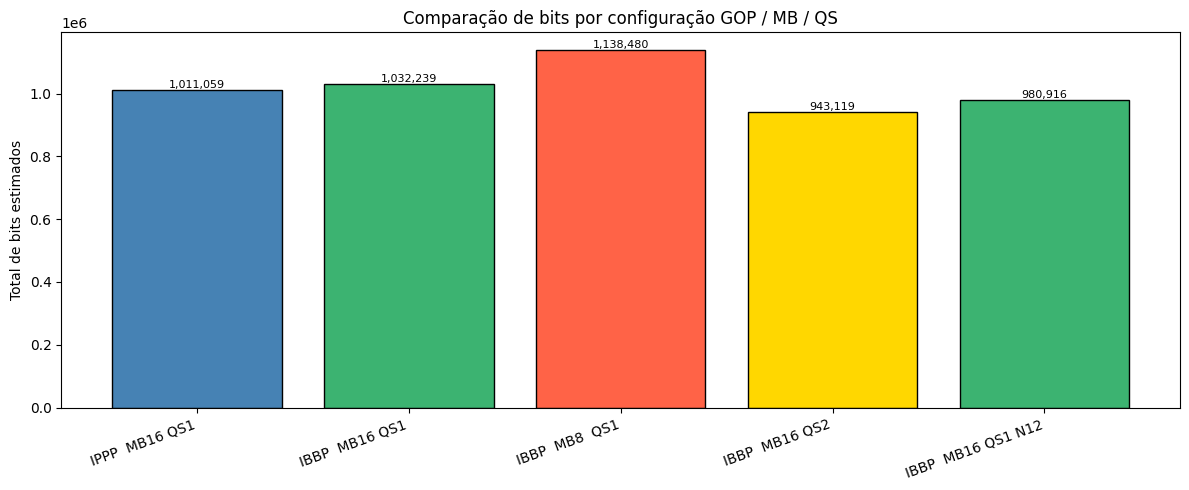

In [ ]:
# --- Gráfico comparativo de bits por configuração ---
if 'results' in dir() and results:
    labels = [r['label'] for r in results]
    bits   = [r['bits'] for r in results]

    colors = ['steelblue' if r['M'] == 1 else
              ('tomato' if r['mb'] == 8 else
               ('gold' if r['qs'] > 1 else 'mediumseagreen'))
              for r in results]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(labels, bits, color=colors, edgecolor='black')
    ax.set_ylabel('Total de bits estimados')
    ax.set_title('Comparação de bits por configuração GOP / MB / QS')
    ax.set_xticklabels(labels, rotation=20, ha='right')
    for bar, b in zip(bars, bits):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{b:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

In [20]:
# =============================================================
# EXPERIMENTO — Vídeo MP4 (input.mp4)
# Usa a função crop_frames_to_multiples_of_8 da professora
# =============================================================

VIDEO_PATH = 'video sequences/input.mp4'

if os.path.isfile(VIDEO_PATH):
    print("A extrair frames do vídeo (pode demorar)...")
    frames_video = crop_frames_to_multiples_of_8(VIDEO_PATH)
    # Limitar a 30 frames para demo rápida
    frames_demo = frames_video[:30]
    print(f"Usando {len(frames_demo)} frames para o experimento.")

    _, bits_video = encode_sequence(
        frames_demo,
        gop_N=9, gop_M=3,
        block_size=16, search_range=8,
        quant_scale=1,
        output_dir='compressed'
    )
    print(f"\nVídeo input.mp4 (30 frames) | Bits estimados: {bits_video:,}")
else:
    print(f"[INFO] Vídeo '{VIDEO_PATH}' não encontrado.")

A extrair frames do vídeo (pode demorar)...
Usando 30 frames para o experimento.

ENCODER | GOP N=9 M=3 | MB=16×16 | SR=8 | QS=1
Sequência GOP (30 frames): ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'I', 'B']...
  Frame   0 [I] | bits estimados:  350,089
  Frame   1 [B] | bits estimados:  478,500
  Frame   2 [B] | bits estimados:  481,863
  Frame   3 [P] | bits estimados:  659,340
  Frame   4 [B] | bits estimados:  215,307
  Frame   5 [B] | bits estimados:  209,982
  Frame   6 [P] | bits estimados:  254,958
  Frame   7 [B] | bits estimados:  214,201
  Frame   8 [B] | bits estimados:  210,088
  Frame   9 [I] | bits estimados:  362,888
  Frame  10 [B] | bits estimados:  504,420
  Frame  11 [B] | bits estimados:  505,544
  Frame  12 [P] | bits estimados:  697,324
  Frame  13 [B] | bits estimados:  221,849
  Frame  14 [B] | bits estimados:  225,444
  Frame  15 [P] | bits estimados:  254,411
  Frame  16 [B] | bits estimados:  221,384
  Frame  

---
## Resumo dos Ficheiros Gerados

Os ficheiros comprimidos (dados DCT quantizados + vetores de movimento) são guardados na pasta `compressed/` em formato `.pkl` (pickle), um por cada configuração testada.

Cada ficheiro contém:
- `compressed`: lista de dicionários com `q_frame`, `mv_list`, `type`, etc.
- `gop_seq`: sequência de tipos de frame
- `params`: parâmetros usados na codificação

Estes ficheiros serão lidos na **Parte 2** (decoder + avaliação de qualidade PSNR/SSIM).

In [ ]:
# Lista os ficheiros comprimidos gerados
if os.path.isdir('compressed'):
    files = sorted(os.listdir('compressed'))
    print(f"Ficheiros em 'compressed/' ({len(files)} total):")
    for f in files:
        size_kb = os.path.getsize(os.path.join('compressed', f)) / 1024
        print(f"  {f:<60} ({size_kb:.1f} KB)")
else:
    print("Pasta 'compressed/' ainda não existe. Execute os experimentos acima.")

Ficheiros em 'compressed/' (5 total):
  compressed_N12_M3_MB16_QS1.pkl                               (5682.2 KB)
  compressed_N9_M1_MB16_QS1.pkl                                (5666.9 KB)
  compressed_N9_M3_MB16_QS1.pkl                                (73456.1 KB)
  compressed_N9_M3_MB16_QS2.pkl                                (5678.7 KB)
  compressed_N9_M3_MB8_QS1.pkl                                 (5816.9 KB)
